# MEAI 502 — Applied Machine Learning
### Lab 1 · Setting Up, and Learning to Look at Data

Dr. Naila Marir · College of Engineering, Effat University · Fall 2026

---

Machine learning has a shape, and most of that shape is not the model. Today you will learn the shape,
meet the tools, and get as far as a professional gets before writing a single line of modelling code:
**you will know your data.** In Lab 2 you will train a model on it.

**The goal of this lab:** understand how a machine learning project works from end to end, and carry a
real medical dataset through the first three stages of it.

Parts 1–3 are tools and vocabulary. **Part 4 is the lab** — that is where you meet the data.

| | |
|---|---|
| **Prerequisites** | A Google account. Python: variables, lists, functions, loops. |
| **Deliverable** | This notebook with both `# TODO` cells completed, renamed `MEAI502_Lab1_<YourName>.ipynb`, on Blackboard. |
| **Assessment** | Exercise 60 %, reflection 40 %. See Part 5. |

Read each text cell, run the code cell under it, **in order, top to bottom**.

---
# Part 1 — Getting Set Up
*≈ 20 minutes*

## 1.1 Google Colab

Colab is a Python notebook that runs on Google's computers, in your browser. Nothing to install.

1. Go to **https://colab.research.google.com** and sign in.
2. `File → New notebook`, then click the title to rename it.
3. It saves itself to Google Drive, in a folder called **Colab Notebooks**.

A notebook is a list of **cells**: *code cells* run Python, *text cells* hold Markdown. Hover between
two cells to get the **+ Code** / **+ Text** buttons. **`Shift + Enter`** runs a cell and moves on —
that is the only shortcut you need today.

Run the cell below.

In [ ]:
print("Hello, MEAI 502!")

### The one trap to know about

A notebook remembers **values**, not the order you see on screen. Run the next two cells in order.

In [ ]:
x = 10
print("x is", x)

In [ ]:
print("x squared is", x ** 2)

Now go back, change `x` to `99`, run **only** that cell, and run this one again without
re-running anything else. The answer will be wrong, and nothing will warn you.

The numbers `[1] [2] [3]` on the left tell you the order things *actually* ran in.

> **Before you submit anything: `Runtime → Restart and run all`.**
> If it does not survive that, it is not a result.

## 1.2 The runtime

The **runtime** is the machine Google lends you. Your variables, packages and files live there.

- `Runtime → Change runtime type` → **CPU** is all you need until deep learning (MEAI 505).
- `Runtime → Restart session` clears every variable.
- The free tier disconnects after about **90 minutes idle**.
- Anything you `!pip install` is **gone next session** — so keep the install line in the notebook.

Everything this lab needs is already installed. Check what you have:

In [ ]:
import sys, numpy, pandas, matplotlib, sklearn
print("Python      ", sys.version.split()[0])
print("NumPy       ", numpy.__version__)
print("pandas      ", pandas.__version__)
print("scikit-learn", sklearn.__version__)

## 1.3 VS Code — for later, not for today

Colab is where you explore. **VS Code** is a code editor on your own laptop, and it is where a project
with many files, a debugger and Git eventually lives. You will need it for your applied project.
Set it up once, at home:

1. Install **Python 3.11+** from python.org and **VS Code** from code.visualstudio.com.
2. In VS Code, install the **Python** and **Jupyter** extensions (Microsoft).
3. Give the project its own environment:

```bash
mkdir meai502 && cd meai502
python -m venv .venv                 # a private Python just for this project
source .venv/bin/activate            # Windows:  .venv\Scripts\activate
pip install numpy pandas matplotlib seaborn scikit-learn jupyter
```

4. `File → Open Folder…` → `meai502`, drop this `.ipynb` inside, open it, then
   **Select Kernel → Python Environments → .venv**.

> **Why an environment per project?** One project needs scikit-learn 1.3, another needs 1.8. A `venv`
> keeps them from fighting.

---
# Part 2 — How an ML Project Works
*≈ 20 minutes*

A machine learning project is **not** "load data, call `.fit()`, publish". It is a cycle of eight
stages, and the last one sends you back to the first.

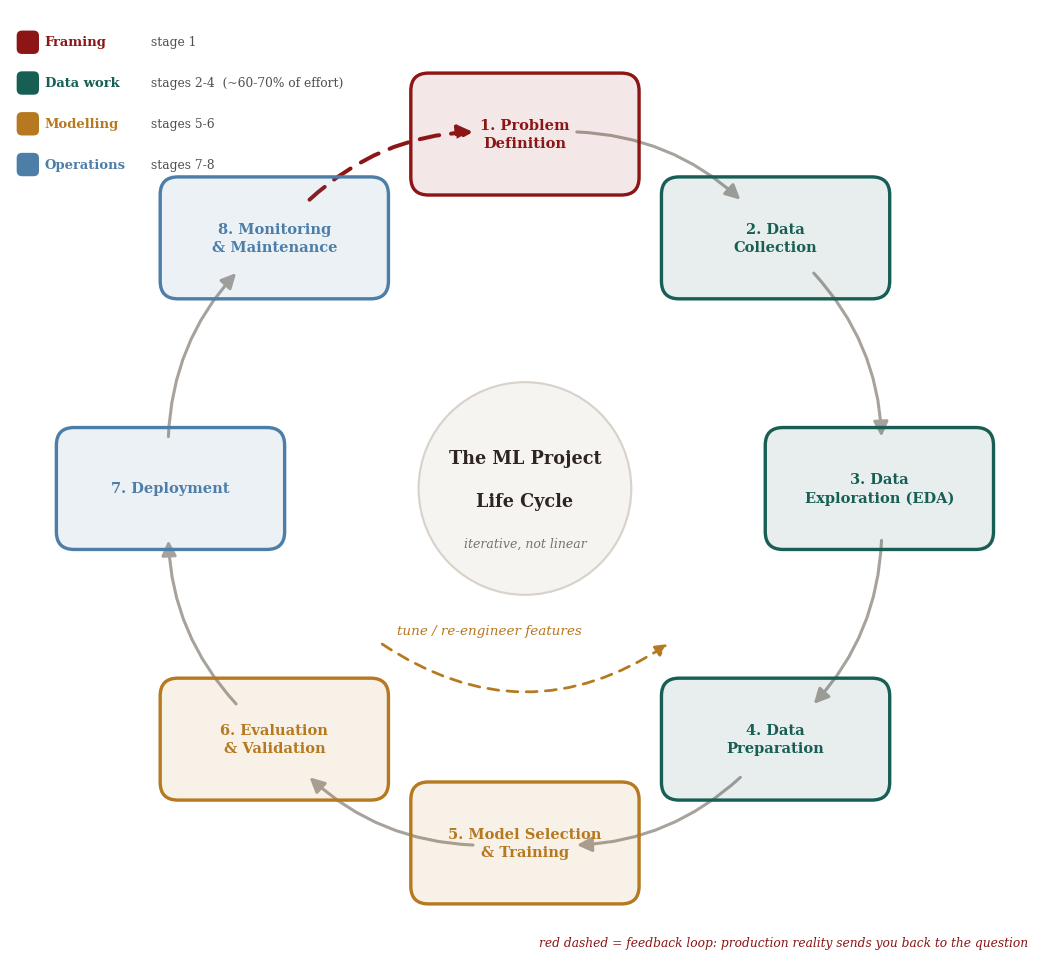

*Figure 1 — The machine learning project life cycle. Grey arrows are the normal flow; the amber dashed
arrow is the tuning loop; the red dashed arrow is the feedback from production back to the question.*

### The eight stages

| # | Stage | What it is *for* | Classic mistake |
|---|---|---|---|
| 1 | **Problem definition** | Turn a vague need into a precise task with a measurable notion of success | Optimising accuracy when the decision needs recall |
| 2 | **Data collection** | Get data that represents the population the model will actually serve | A convenience sample from one site or device |
| 3 | **Data exploration (EDA)** | Understand quality and relationships *before* modelling | Going straight to `.fit()` |
| 4 | **Data preparation** | Build a clean, leak-free feature matrix | Scaling before splitting |
| 5 | **Model training** | Learn the mapping — and beat a baseline | No baseline, so no idea if it is any good |
| 6 | **Evaluation** | Estimate honestly how it behaves on unseen data | One accuracy number on imbalanced data |
| 7 | **Deployment** | Put it where the decision is actually made | Preprocessing differs in production |
| 8 | **Monitoring** | Keep it correct while the world changes | "Fire and forget" |

Two things to take away:

- **It is a loop, not a line.** You will go back. Going back is the method, not a failure.
- **The data stages are the expensive ones.** Stages 2–4 are roughly **60–70 %** of the real effort.
  Modelling is the small, glamorous part.

**Today: stages 1, 2 and 3. Lab 2: stages 4, 5 and 6.** Stages 7 and 8 come later in the programme.

---
# Part 3 — The Five Libraries
*≈ 15 minutes*

Five libraries do almost all the work. Meet them one at a time — one cell each.

| Library | Mental model | Stages |
|---|---|---|
| **NumPy** | A fast grid of numbers you can do arithmetic on all at once | 4, 5 |
| **pandas** | A spreadsheet you drive with code (`DataFrame`) | 2, 3, 4 |
| **Matplotlib** | A canvas where every element is an object you can change | 3, 6 |
| **seaborn** | Matplotlib with opinions; it speaks DataFrames | 3, 6 |
| **scikit-learn** | One interface for every algorithm: `fit` → `predict` | 4, 5, 6 |

Run this setup cell first.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# House style for every plot below. Set it once, at the top - a course, a paper
# or a thesis should look like one document, not twenty.
PALETTE = ["#8C1515", "#4D7EA8", "#175E54", "#B7791F"]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42          # one seed everywhere, so results repeat
print("ready")

### NumPy — the array

One operation applies to every element at once. No loop. That is the whole idea, and it is why
everything else in the stack is built on top of it.

In [ ]:
a = np.array([1, 2, 3, 4, 5])

print("a       ", a)
print("a * 2   ", a * 2)
print("mean    ", a.mean())

### pandas — the table

A `DataFrame` is a table with named columns. This is what your data will arrive as.

In [ ]:
df = pd.DataFrame({
    "student": ["Sara", "Omar", "Layan", "Yousef"],
    "score":   [88, 72, 95, np.nan],        # np.nan = a missing value
    "track":   ["AI", "AI", "Data", "Data"],
})

print(df)
print("\nmissing scores:", df["score"].isna().sum())

### Matplotlib — the drawing engine

A figure is a canvas, axes are the plots on it, and every element is an object you can address.

In [ ]:
fig, ax = plt.subplots(figsize=(5, 2.6))
ax.plot([1, 2, 3, 4, 5], [2.1, 3.9, 6.2, 7.8, 10.1], marker="o")
ax.set_title("Matplotlib: you control every element")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

### seaborn — statistics, plotted

One line, and it understands DataFrames. You will use it constantly in Stage 3.

In [ ]:
fig, ax = plt.subplots(figsize=(4.4, 2.8))
sns.barplot(data=df, x="track", y="score", errorbar=None, ax=ax)
ax.set_title("seaborn: one line, sensible defaults")
plt.tight_layout()
plt.show()

### scikit-learn — the machine learning

Every model in the library has the same two methods. Learn the pattern once and it never changes:

```python
model.fit(X, y)        # learn from data
model.predict(X_new)   # produce predictions
```

In [ ]:
from sklearn.linear_model import LinearRegression

X = np.array([[1], [2], [3], [4], [5]])      # features: always 2-D
y = np.array([2.1, 3.9, 6.2, 7.8, 10.1])     # target:   1-D

model = LinearRegression()
model.fit(X, y)

print("predict x = 6 ->", model.predict([[6]]).round(2))

---
# Part 4 — Stages 1 to 3 on Real Data
*≈ 50 minutes — this is the heart of the lab*

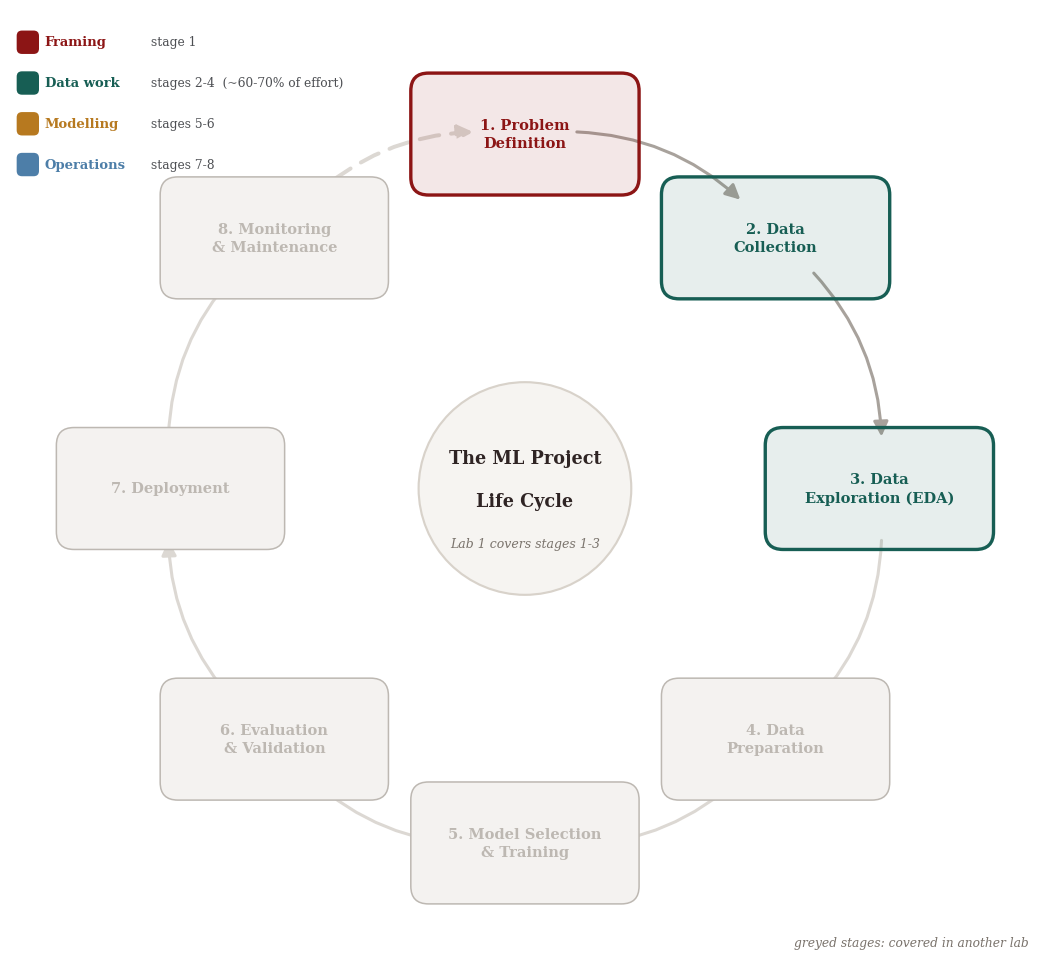

**The dataset — Breast Cancer Wisconsin (Diagnostic).** 569 biopsies. For each one, 30 numeric
measurements taken from a digitised image of a fine-needle aspirate — radius, texture, concavity and
so on — and a diagnosis: **malignant** or **benign**. It ships inside scikit-learn, so there is
nothing to download.

## Stage 1 — Problem Definition

> **The need.** A pathology lab wants a second-opinion tool that flags biopsies likely to be
> malignant, so a radiologist reviews the risky ones first.
>
> **ML task:** binary classification.
> **Target `y`:** 1 = malignant, 0 = benign.
> **Features `X`:** the 30 image measurements.
>
> **The metric: recall on the malignant class** — of all the truly malignant cases, what fraction do
> we catch? We will also report precision, so we know how many false alarms that costs.
>
> **Why not accuracy?** Because the two mistakes are not equally bad. A false alarm costs one extra
> review. A missed malignancy can cost a life. The metric has to encode that asymmetry.

No code yet. Stage 1 is a thinking stage — and skipping it is how projects go wrong.

In [ ]:
# Write the frame down, so it travels with the notebook.
PROBLEM = {
    "task":   "binary classification",
    "target": "1 = malignant, 0 = benign",
    "metric": "recall on the malignant class",
}
for k, v in PROBLEM.items():
    print(f"{k:7}: {v}")

## Stage 2 — Data Collection

A real project spends weeks here: getting access, checking consent, writing a data dictionary. Ours
is one function call — but notice what we still check straight away.

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)

X = data.data          # the 30 measurements, as a DataFrame
y_raw = data.target    # scikit-learn encodes 0 = malignant, 1 = benign

X.shape                # (rows, columns)

### Re-encode the target

scikit-learn ships this dataset with `0 = malignant`. We want the opposite, because **the positive
class should be the thing you are trying to detect** — every metric you compute is about class `1`.
Get this backwards and your recall will quietly measure the wrong thing.

In [ ]:
y = (y_raw == 0).astype(int)     # now: 1 = malignant, 0 = benign
y.name = "malignant"

print("first 10 labels:", y.head(10).tolist())
print("total samples   :", len(y))

### Look at the actual table

Before anything else: **look at your data.** Not a summary of it — the rows themselves.

In [ ]:
X.head()

Thirty columns is too many to read at once, so they are grouped. The 30 come from **10 base
measurements** of the cell nuclei, each reported three ways: the **mean**, the **error** and the
**worst** (largest) value in the image.

In [ ]:
print("the 10 base measurements:")
for name in X.columns[:10]:
    print("  ", name.replace("mean ", ""))

print("\nand each appears three times, e.g.:")
print([c for c in X.columns if "radius" in c])

## Stage 3 — Data Exploration (EDA)

Four questions, in this order:

1. Is anything **missing**?
2. What do the numbers **look like**?
3. Is the target **balanced**?
4. Which features **relate** to the diagnosis?

### 3.1 Is anything missing?

In [ ]:
print("missing values in the whole table:", int(X.isna().sum().sum()))

Zero. That is a teaching dataset, not real life — expect to spend most of Stage 4 on exactly the
problem this file does not have.

### 3.2 What do the numbers look like?

`describe()` on all 30 columns is unreadable, so look at four at a time.

In [ ]:
X[["mean radius", "mean texture", "mean area", "mean concavity"]].describe().round(2)

Notice the **scales**: `mean area` runs into the hundreds while `mean concavity` sits below 1.
Some models do not care. Others care a great deal. That is a Stage 4 problem, and we will deal with
it in Lab 2.

### 3.3 Is the target balanced?

In [ ]:
counts = y.value_counts().rename({0: "benign", 1: "malignant"})
print(counts)
print(f"\nmalignant rate: {y.mean():.1%}")

In [ ]:
fig, ax = plt.subplots(figsize=(4.2, 3))
labels = y.map({0: "benign", 1: "malignant"})
sns.countplot(x=labels, hue=labels, legend=False, ax=ax)
ax.set_title("Class balance")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Do the arithmetic.** 37.3 % malignant means 62.7 % benign. So a "model" that always answered
*benign* would already be right 62.7 % of the time — while catching **zero** cancers.

That single number is the reason our metric is recall and not accuracy. Hold on to it: in Lab 2 it
becomes the bar our real model has to clear.

### 3.4 Which features relate to the diagnosis?

`corrwith` scores every column on how strongly it moves with the target, between −1 and +1.

In [ ]:
corr = X.corrwith(y).sort_values(ascending=False)

print("most associated with MALIGNANT:")
print(corr.head(5).round(3))

All positive and all fairly strong — good news. It means the signal we need is present in the
features, before we have trained anything. If every correlation had been near zero, no model would
have saved us.

In [ ]:
top4 = corr.head(4).index.tolist()

plot_df = X[top4].copy()
plot_df["diagnosis"] = y.map({0: "benign", 1: "malignant"})

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, feature in zip(axes, top4):
    sns.boxplot(data=plot_df, x="diagnosis", y=feature,
                hue="diagnosis", legend=False, ax=ax)
    ax.set_title(feature, fontsize=10)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

**How to read a boxplot:** the box is the middle half of the data, the line inside it is the
median, and the dots are outliers.

The two boxes barely overlap. That is what "this feature separates the classes" looks like. If they
had overlapped completely, the feature would be useless.

### What Stage 3 told us

Write this down — it is the output of the stage, and it is what you hand to Stage 4:

1. **569 rows, 30 numeric features, no missing values.** Nothing to clean.
2. **The features are on wildly different scales** (area in the hundreds, concavity below 1).
   Some models will need that fixed.
3. **37.3 % malignant.** Moderately imbalanced — accuracy will flatter any model, so we use recall.
4. **Several features separate the classes clearly.** There is real signal here.

That is a complete Stage 3. Notice that we have still not trained anything — and we already know
what the model will need, and how we will judge it.

---
# Part 5 — Wrap-up
*≈ 15 minutes*

## Exercise — explore two features of your own choosing  *(60 %)*

Pick **two features that are not in the top four** above — anything from `X.columns`. For each one:

1. Plot it by diagnosis (a boxplot, exactly as we did).
2. Report its correlation with the target.
3. Write one sentence saying whether you would expect it to help a model, and why.

The marks are in step 3.

In [ ]:
# TODO 1 - your two features.

my_features = ["...", "..."]        # <-- two names from X.columns

# 1) their correlation with the target
# print(corr[my_features].round(3))

# 2) a boxplot of each, by diagnosis
#    (copy the plotting cell from 3.4 and change top4 -> my_features)


# 3) Your answer, in a comment. One sentence per feature:
# Feature 1: ...
# Feature 2: ...

assert "..." not in my_features, "Choose two real column names from X.columns" 

## Reflection — frame a problem from your own field  *(40 %)*

Stage 1 only. Pick a problem you actually care about — health, energy, transport, education, finance,
anything — and answer three questions about it. One or two sentences each.

Be concrete about the **target variable** and the **metric**: those are the two places most projects
go wrong. "Predict student performance" is not a target variable. "High accuracy" is not a metric.

In [ ]:
# TODO 2 - Stage 1 for your own problem.

my_problem = {
    "decision": "...",   # who uses the prediction, and what do they do differently because of it?
    "target":   "...",   # what exactly is y? name it, and say whether it is a class or a number
    "metric":   "...",   # how will you judge it, and why that metric for THIS decision?
}

for question, answer in my_problem.items():
    print(f"{question:9}: {answer}")
    assert answer != "...", f"Still to do: {question}" 

## Before you submit

1. `Runtime → Restart and run all` — the whole notebook must run top to bottom without errors.
2. `File → Download → .ipynb`, rename it `MEAI502_Lab1_<YourName>.ipynb`.
3. Upload it to Blackboard.

---

## Next lab — **Stages 4 to 6: your first model**

You now know this dataset. Lab 2 turns it into a model:

- **Stage 4** — split the data into a training set and a sealed test set, and fix those wild scales
- **Stage 5** — train a baseline first, then a real model
- **Stage 6** — measure it with the metric we chose today, and read a confusion matrix

**Before Lab 2:** re-run this notebook with `Restart and run all`, and be ready to say what
*recall* is and why we chose it.

---

### References

1. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3rd ed.), Ch. 2.
2. pandas — *10 minutes to pandas* — https://pandas.pydata.org/docs/user_guide/10min.html
3. seaborn tutorial — https://seaborn.pydata.org/tutorial.html
4. Google Colab — *Overview of Colaboratory Features* — https://colab.research.google.com/notebooks/basic_features_overview.ipynb
5. Dua, D. & Graff, C. — UCI Machine Learning Repository, *Breast Cancer Wisconsin (Diagnostic)*.

---
*MEAI 502 Applied Machine Learning — Lab 1 — Dr. Naila Marir — Effat University, Fall 2026*